In [2]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from sklearn.preprocessing import MinMaxScaler

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict

In [4]:
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))

tqdm.pandas()

In [5]:
import yfinance as yf
from datetime import date

start_date = '2000-01-01'
end_date = '2024-12-31'

ticker_symb = 'BP'

df = yf.download(ticker_symb, start=start_date, end=end_date)

# Inspect the data
print(df.head())
print(df.info())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker             BP         BP         BP         BP       BP
Date                                                           
2000-01-03  18.153732  18.308068  18.057273  18.288776  2039300
2000-01-04  18.057272  18.346651  17.980104  18.037980  3825800
2000-01-05  18.674610  18.674610  17.825764  17.883640  4055900
2000-01-06  18.713182  18.713182  18.308052  18.423803  4034700
2000-01-07  18.365927  18.365927  18.057256  18.057256  4027200
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6288 entries, 2000-01-03 to 2024-12-30
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   (Close, BP)   6288 non-null   float64
 1   (High, BP)    6288 non-null   float64
 2   (Low, BP)     6288 non-null   float64
 3   (Open, BP)    6288 non-null   float64
 4   (Volume, BP)  6288 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 294.8 KB
None


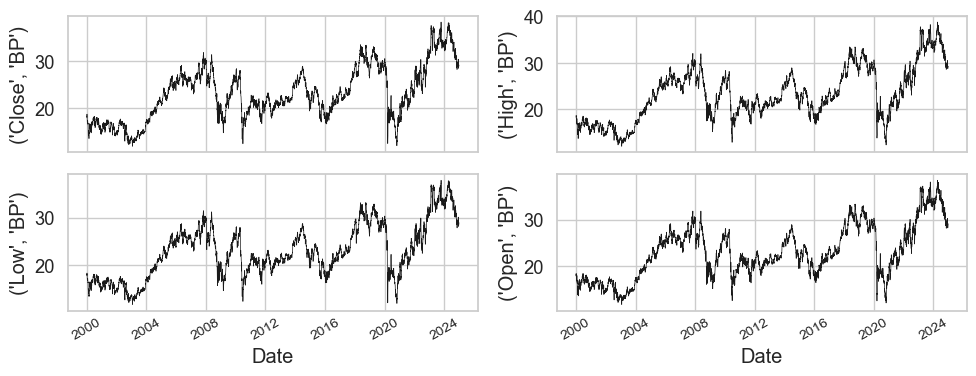

In [6]:
import matplotlib.dates as mdates

df_plot = df.copy()
ncols = 2
nrows = 2
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(10, 4.0))
for i, ax in enumerate(fig.axes):
    sns.lineplot(data=df_plot.iloc[:, i], ax=ax, color='k', linewidth=0.5)
    ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.tight_layout()
plt.show()

data.shape = (6288, 5)


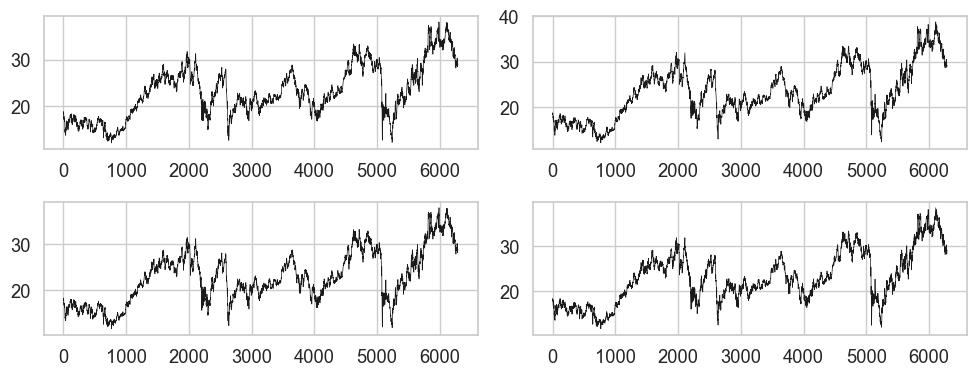

In [7]:
data = df.values
print(f"data.shape = {data.shape}")
plt.figure(figsize=(10, 4.0))
for idx in range(4):
    i = idx // nrows
    j = idx % nrows
    plt.subplot(nrows, ncols, idx+1)
    plt.plot(data[:,idx], 'k-', linewidth=0.5)
    
plt.tight_layout()

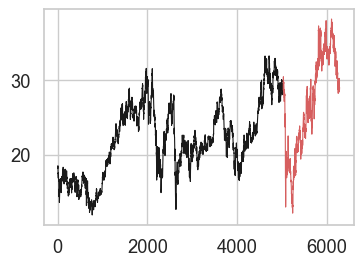

In [8]:
# Train test split
stock_data = df.values
data_train_len = int(0.8 * stock_data.shape[0])
# We take the mean value of the high and the low of the day price as the data for prediction.
data_train = np.mean(stock_data[:data_train_len,[1, 2]], axis=1, keepdims=True)
data_test = np.mean(stock_data[data_train_len:,[1, 2]], axis=1, keepdims=True)
axis_train = np.arange(0, data_train_len)
axis_test = np.arange(data_train_len, stock_data.shape[0])
plt.figure(figsize=(4, 2.8))
plt.plot(axis_train, data_train.ravel(), 'k-', linewidth=0.8)            # no need for ravel though
plt.plot(axis_test, data_test.ravel(), 'r-', linewidth=0.8)
plt.show()

In [9]:
print(f"stock_data.shape = {stock_data.shape}")
print(f"data_train.shape = {data_train.shape}")
print(f"data_test.shape = {data_test.shape}")

stock_data.shape = (6288, 5)
data_train.shape = (5030, 1)
data_test.shape = (1258, 1)


In [10]:
# We normalize the data by using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(data_train)
train_scaled = scaler.transform(data_train)
test_scaled = scaler.transform(data_test)

print(f"train_scaled.shape = {train_scaled.shape}")
print(f"test_scaled.shape = {test_scaled.shape}")

train_scaled.shape = (5030, 1)
test_scaled.shape = (1258, 1)


In [11]:
# Create sequences and labels for training data
seq_length_train = 50        # number of time steps to look back for making prediction
input_size = 1
output_size = 1
X_train = np.zeros(shape=(train_scaled.shape[0] - seq_length_train, seq_length_train, input_size), dtype=np.float32)
y_train = np.zeros(shape=(train_scaled.shape[0] - seq_length_train, output_size), dtype=np.float32)

for i in range(train_scaled.shape[0] - seq_length_train):
    X_train[i] = train_scaled[i:i+seq_length_train]
    y_train[i] = train_scaled[i+seq_length_train]


X_train = torch.from_numpy(X_train)
y_train = torch.from_numpy(y_train)
print(f"X_train.shape = {X_train.shape}")
print(f"y_train.shape = {y_train.shape}")

X_train.shape = torch.Size([4980, 50, 1])
y_train.shape = torch.Size([4980, 1])


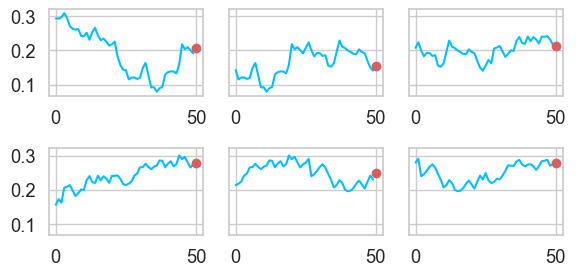

In [22]:

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(6, 3), sharey=True)
for idx in range(2 * 3):
    i, j = idx // 3, idx % 3
    ax[i][j].plot(np.arange(0, seq_length_train), X_train[25 * idx])
    ax[i][j].plot(seq_length_train, y_train[25 * idx], 'ro')
plt.tight_layout()

In [23]:
# Create sequences and labels for testing data
seq_length_test = 30
X_test = np.zeros(shape=(test_scaled.shape[0] - seq_length_test, seq_length_test, input_size), dtype=np.float32)
y_test = np.zeros(shape=(test_scaled.shape[0] - seq_length_test, input_size), dtype=np.float32)

for i in range(test_scaled.shape[0] - seq_length_test):
    X_test[i] = test_scaled[i:i+seq_length_test]
    y_test[i] = test_scaled[i+seq_length_test]

X_test = torch.from_numpy(X_test)
y_test = torch.from_numpy(y_test)
print(f"X_test.shape = {X_test.shape}")
print(f"y_test.shape = {y_test.shape}")

X_test.shape = torch.Size([1228, 30, 1])
y_test.shape = torch.Size([1228, 1])


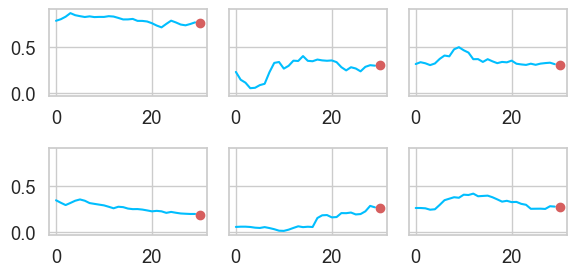

In [25]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(6, 3), sharey=True)
for idx in range(2 * 3):
    i, j = idx // 3, idx % 3
    ax[i][j].plot(np.arange(0, seq_length_test), X_test[50 * idx])
    ax[i][j].plot(seq_length_test, y_test[50 * idx], 'ro')
plt.tight_layout()

In [19]:
class StockModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers):
        super(StockModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                            num_layers=num_layers, batch_first=True)
        self.lin = nn.Linear(hidden_size, output_size)
    
    def forward(self, input):
        # output, _ = self.rnn(inputs)
        # output = self.lin(output[:,-1,:])
        out, (hn, cn) = self.lstm(input)        # we don't use hn and cn in our case
        out = self.lin(out[:,-1,:])
        return out

In [29]:
input_size = 1
hidden_size = 64
num_layers = 3
model = StockModel(input_size=input_size, hidden_size=hidden_size, output_size=1, num_layers=num_layers)

# Test the model on random input data
np.random.seed(seed=42)
X = torch.randn(size=(32, seq_length_train, input_size))
out_lstm, (h_n, c_n) = model.lstm(X)
Y = model(X)
print(f"out_lstm.shape = {out_lstm.shape}")
print(f"h_n.shape = {h_n.shape}")
print(f"c_n.shape = {c_n.shape}")
print(f"Y.shape = {Y.shape}")

out_lstm.shape = torch.Size([32, 50, 64])
h_n.shape = torch.Size([3, 32, 64])
c_n.shape = torch.Size([3, 32, 64])
Y.shape = torch.Size([32, 1])


In [30]:
BATCH_SIZE = 32
dataset_train = TensorDataset(X_train, y_train)
dataloader_train = DataLoader(dataset_train, batch_size=BATCH_SIZE, shuffle=True)
dataset_test = TensorDataset(X_test, y_test)
dataloader_test = DataLoader(dataset_test, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of batches in train set: {len(dataloader_train)}")
print(f"Number of batches in test set: {len(dataloader_test)}")

Number of batches in train set: 156
Number of batches in test set: 39


In [31]:
EPOCHS = 10
train_hist = []
test_hist = []
loss_fn = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [32]:
for epoch in range(EPOCHS):
    total_loss_train = 0.0
    model.train()
    for X_batch, y_batch in dataloader_train:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
        total_loss_train += loss.item()

    average_loss_train = total_loss_train / len(dataloader_train)
    train_hist.append(average_loss_train)

    model.eval()
    with torch.no_grad():
        total_loss_test = 0.0
        for X_batch, y_batch in dataloader_test:
            y_pred = model(X_batch)
            loss_test = loss_fn(y_pred, y_batch)

            total_loss_test += loss_test.item()

        average_loss_test = total_loss_test / len(dataloader_test)
        test_hist.append(average_loss_test)

        print(f"Epoch [{epoch + 1} / {EPOCHS}] -- Training loss: {average_loss_train:5.4e} | Test Loss: {average_loss_test:5.4e}")

Epoch [1 / 100] -- Training loss: 1.6739e-02 | Test Loss: 3.6054e-03
Epoch [2 / 100] -- Training loss: 9.9207e-04 | Test Loss: 2.0914e-03
Epoch [3 / 100] -- Training loss: 7.0704e-04 | Test Loss: 1.8023e-03
Epoch [4 / 100] -- Training loss: 5.7507e-04 | Test Loss: 2.0131e-03
Epoch [5 / 100] -- Training loss: 5.7864e-04 | Test Loss: 1.6293e-03
Epoch [6 / 100] -- Training loss: 3.8711e-04 | Test Loss: 1.1717e-03
Epoch [7 / 100] -- Training loss: 3.2275e-04 | Test Loss: 7.0339e-04
Epoch [8 / 100] -- Training loss: 3.6482e-04 | Test Loss: 1.0711e-03
Epoch [9 / 100] -- Training loss: 3.4388e-04 | Test Loss: 6.5685e-04
Epoch [10 / 100] -- Training loss: 3.0227e-04 | Test Loss: 6.6011e-04
Epoch [11 / 100] -- Training loss: 3.0309e-04 | Test Loss: 8.0691e-04
Epoch [12 / 100] -- Training loss: 3.0877e-04 | Test Loss: 8.1935e-04
Epoch [13 / 100] -- Training loss: 3.1111e-04 | Test Loss: 8.3814e-04
Epoch [14 / 100] -- Training loss: 4.1478e-04 | Test Loss: 1.8573e-03
Epoch [15 / 100] -- Training 

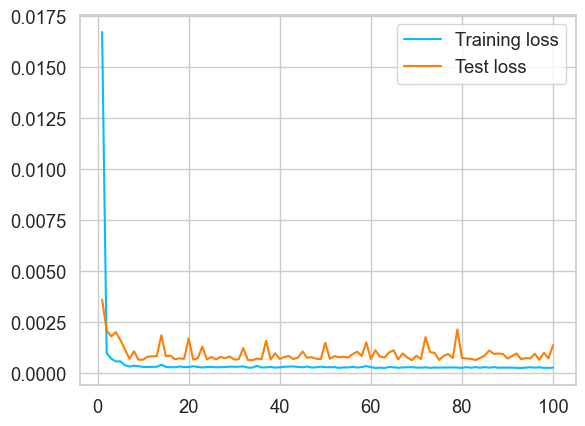

In [33]:
xx = np.arange(1, len(train_hist)+1)
plt.plot(xx, train_hist, scalex=True, label='Training loss')
plt.plot(xx, test_hist, label='Test loss')
plt.legend()
plt.show()

In [38]:
num_forecast_steps = 30
sequence_to_plot = X_test.squeeze().cpu().numpy()
print(f"sequence_to_plot.shape = {sequence_to_plot.shape}")
historical_data = sequence_to_plot[-1]
print(historical_data)

sequence_to_plot.shape = (1228, 30)
[0.79682    0.7986898  0.8155178  0.80009216 0.7989235  0.81878996
 0.82790506 0.81785506 0.8000921  0.803598   0.8092073  0.7984561
 0.81855625 0.8143492  0.8017282  0.7916782  0.8536145  0.85034245
 0.8575878  0.8543157  0.84216213 0.8052341  0.79868984 0.7919119
 0.7767199  0.77858967 0.784199   0.7872374  0.79167813 0.7979886 ]


In [ ]:
forecasted_values = []
with torch.no_grad():
    for _ in range(num_forecast_steps):
        historical_data_tensor = torch.as_tensor(historical_data).view(1, )